In [1]:
import drjit as dr
import xdesign as xd
import cupy as xp
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th
import torch as th
from drjit.cuda.ad import Array2f, Array1f, ArrayXf, Float, TensorXf
import numpy as np

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

In [2]:
import sys
sys.path.append("src")
import xrt_toolkit as xtk

Loaded weights from gpu_3D_spline_weights_drjit.npz.


In [3]:
def create_phantom(N_side):
    seed = 0
    np.random.seed(seed)
    p1 = xd.Foam(size_range=[0.1, 0.01], gap=0.025, porosity=0.5)
    phantom = xd.discrete_phantom(p1, N_side-15) * 10
    phantom = np.pad(phantom, 15)
    phantom = np.abs(phantom)
    return xp.array(phantom)

_x = create_phantom(200)
x_th = th.tensor(_x, device=device, dtype=th.float32)
v_shape = x_th.shape
n_angles = v_shape[0]*4
print(v_shape, x_th.min(), x_th.max())

/opt/conda/lib/python3.11/site-packages/xdesign/phantom/phantom.py:375: RuntimeWarning: Reached termination criteria of 500 attempts before adding all of the circles.
  warnings.warn((


torch.Size([215, 215]) tensor(0., device='cuda:0') tensor(10., device='cuda:0')


In [4]:
def set_operators_parallel_beam_dr(N_side, N_angle, N_offset, pitch, angles, t_offset):
    angles = Float(angles)
    A, T = dr.meshgrid(angles, t_offset, indexing='ij')  
    M = N_angle * N_offset
    A = dr.reshape(A, shape=(M,))
    T = dr.reshape(T, shape=(M,))
    c = dr.cos(A)
    s = dr.sin(A)
    
    n_spec = Array2f(c, s) 
    t_unit = Array2f(s, c) * Array2f(-1.0, 1.0)

    t_spec = t_unit * T + pitch * N_side / 2

    return t_spec, n_spec

In [5]:
import xrt_toolkit.util as xrtu

from xrt_toolkit.util.compat import (
    asarray as asarray,
)
from xrt_toolkit.util.dtype import (
    TranslateDType as TranslateDType,
)
from xrt_toolkit.util.mesh import (
    DetectorSpec as DetectorSpec,
    UniformSpec as UniformSpec,
)
from xrt_toolkit.util.misc import (
    broadcast_seq as broadcast_seq,
)
from xrt_toolkit.util.type_traits import (
    int_array_t as int_array_t,
    uint_array_t as uint_array_t,
    float_array_t as float_array_t,
    float_matrix_t as float_matrix_t,
)

import typing as typ
ArrayNNfT = typ.TypeVar("ArrayNNfT", bound=dr.AnyArray)
FloatT = typ.TypeVar("FloatT", bound=dr.AnyArray)
RaySpecT = tuple[ArrayNNfT, ArrayNNfT, UniformSpec]


# @dr.syntax
def cone_beam(
    sod: float,
    sdd: float,
    angles: FloatT,
    detector_spec: DetectorSpec,
    delta = (0.0,0.0),
) -> RaySpecT:
   
    assert 0 < sod < sdd

    Float = type(angles)
    Matrix2 = float_matrix_t(Float, 2)
    Matrix3 = float_matrix_t(Float, 3)

    R = Matrix3(
        *(dr.cos(angles), -dr.sin(angles), 0),
        *(dr.sin(angles), dr.cos(angles), 0),
        *(0, 0, 1),
    )

    ray_t_spec = R @ Matrix3(
        *(0, 0, -sod),
        *(0, 0, 0),
        *(0, 0, 0),
    )
    ray_n_spec = R @ Matrix3(
        *(0, 0, sdd),
        *(1, 0, 0),
        *(0, 1, 0),
    )

    D = detector_spec.ndim + 1
    if D == 2:
        select = lambda mat3: Matrix2(
            *(mat3[0, 0], mat3[0, 2]),
            *(mat3[1, 0], mat3[1, 2]),
        )
        ray_t_spec = select(ray_t_spec)
        ray_n_spec = select(ray_n_spec)

    ll_center = tuple(
        (cs - s) / 2
        for (cs, s) in zip(
            detector_spec.cell_size,
            detector_spec.size,
        )
    )

    ray_u_spec = UniformSpec(
        start=(*ll_center, 1),
        step=(*detector_spec.cell_size, 1e-16),
        num=(*detector_spec.num_cell, 1),
    )

    Array = dr.array_t(ray_t_spec)

    ray_u_spec.start = (ray_u_spec.start[0] + delta[0], ray_u_spec.start[1] + delta[1])
    ray_u_spec = UniformSpec(start=ray_u_spec.start, step=ray_u_spec.step, num=ray_u_spec.num)
    ray_spec = (Array(ray_t_spec), Array(ray_n_spec), ray_u_spec)

    # experimental
    ray_t_spec, ray_n_spec, ray_u_spec = ray_spec
    ArrayNNf = type(ray_t_spec)
    ArrayNf = dr.value_t(ArrayNNf)
    Float = dr.value_t(ArrayNf)
    UInt = dr.value_t(dr.uint32_array_t(ArrayNf))

    D = dr.size_v(ArrayNf)

    u = [None] * D
    for d, (start, step, num) in enumerate(ray_u_spec):
        u[d] = start + step * dr.arange(Float, num)
    uu = ArrayNf(*dr.meshgrid(*u, indexing="ij"))

    i = UInt(0)

    while i < angles.shape[0]:
        H_t = dr.gather(ArrayNNf, ray_t_spec, i)
        ray_t = H_t @ uu

        H_n = dr.gather(ArrayNNf, ray_n_spec, i)
        ray_n = H_n @ uu
        
        i += 1
        
        ray_t_ = TensorXf(ray_t)
        ray_t_c = dr.concat([ray_t_c, ray_t_], axis=1) if i>1 else ray_t_
        ray_n_ = TensorXf(ray_n)
        ray_n_c = dr.concat([ray_n_c, ray_n_], axis=1) if i>1 else ray_n_

    ray_t = Array2f(ray_t_c)
    ray_n = Array2f(ray_n_c)
    ray_spec = (ray_t, ray_n)
    
    return ray_spec

In [6]:
geom = "parallel"

if geom == "cone":
    ray_spec = cone_beam(
        sod=400.0,
        sdd=550.0,
        angles=dr.linspace(Float, 0., dr.pi-0., n_angles),
        detector_spec=DetectorSpec(1.5*v_shape[0], 2*v_shape[0]),
    )
    knot_spec = xtk.UniformSpec(start=(-v_shape[0]//2, -v_shape[0]//2), step=(1, 1), num=(v_shape[0], v_shape[1]))

if geom == "parallel":
    angles = Float(np.linspace(0, np.pi, n_angles, endpoint=False))
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles,
        t_offset = dr.linspace(Float, -(v_shape[0] - 1) / 2 * dr.sqrt(2.0), (v_shape[0] - 1) / 2 * dr.sqrt(2.0), 2*v_shape[0])
    )
    
    ray_spec = (t_spec_dr, n_spec_dr)
    N_ray = max(t_spec_dr.shape[1], t_spec_dr.shape[1])
    knot_spec = xtk.UniformSpec(start=0, step=(1, 1), num=(v_shape[0], v_shape[1]))

## Create data

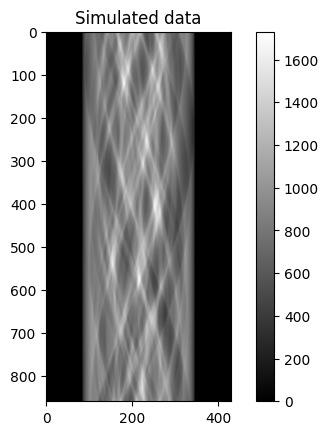

In [7]:
order = 0
x_dr = Float(x_th.reshape(-1))
fp = xtk.xrt_apply
bp = xtk.xrt_adjoint

y_dr = xtk.xrt_apply(ray_spec, knot_spec, order, x_dr)

plt.figure()
plt.imshow(th.asarray(y_dr).cpu().reshape(n_angles, -1), cmap='gray')
plt.colorbar()
plt.title("Simulated data")
plt.show()

### Perturb angles or offsets for calibration XP

In [8]:
rng = dr.rng(seed=0)
if geom == "parallel":
    np_perturb_angles = np.linspace(0., np.pi, n_angles, endpoint=False) + np.random.normal(0, 0.02, n_angles)
    angles_perturbed = Float(np_perturb_angles)
    t_offset_perturbed = dr.linspace(Float, -(v_shape[0] - 1) / 2 * dr.sqrt(2.0), (v_shape[0] - 1) / 2 * dr.sqrt(2.0), 2*v_shape[0]) #+ rng.random(Float, 2*v_shape[0]) * 1
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_perturbed,
        t_offset = t_offset_perturbed
    )
    ray_spec = (t_spec_dr, n_spec_dr)

if geom == "cone":
    ray_spec = cone_beam(
        sod=400.0,
        sdd=550.0,
        angles=dr.linspace(Float, 0, dr.pi, n_angles),
        detector_spec=DetectorSpec(1.5*v_shape[0], 2*v_shape[0]),
        delta = (0.0,0.0) 
    )

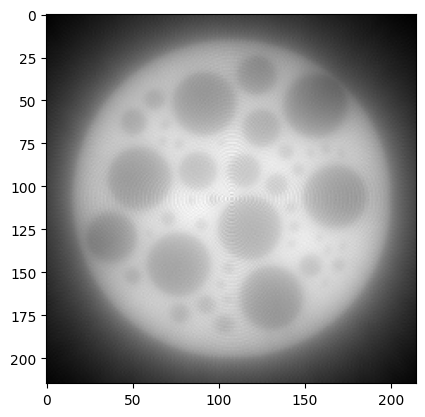

In [9]:
backproj = bp(ray_spec, knot_spec, order, y_dr)
plt.figure()
plt.imshow(th.asarray(backproj).cpu().reshape(v_shape), cmap='gray')


## Naive l2 reconstruction (both cone or parallel beam projections)

0 [234850]
100 [289.155]
200 [286.869]
300 [286.805]
400 [286.799]
Final loss: [286.798]


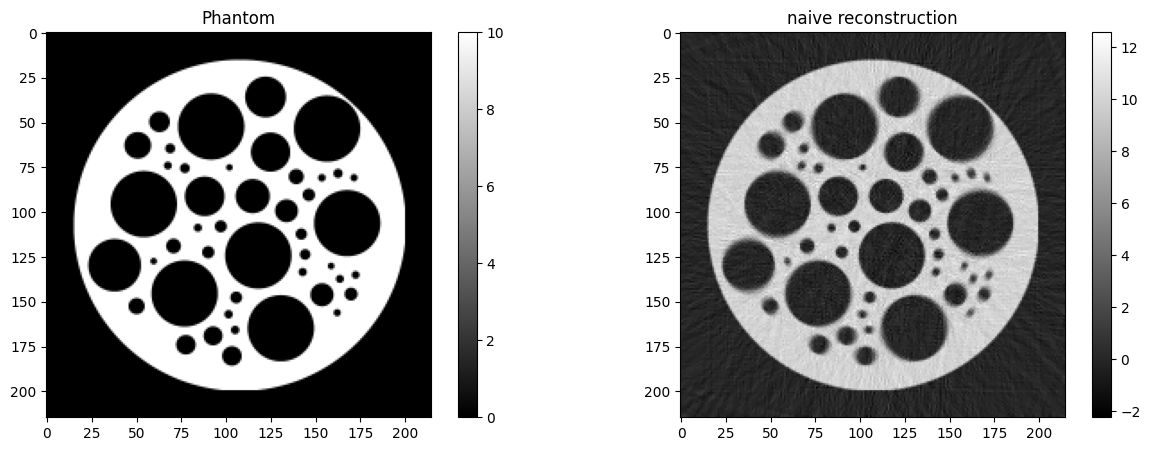

In [10]:
from drjit.opt import Adam, GradScaler, SGD

tv = lambda x: dr.sum(dr.abs(x[1:] - x[:-1])) + dr.sum(dr.abs(x[:,1:] - x[:,:-1]))
def loss(x_input):
    r = fp(ray_spec, knot_spec, order, x_input) - y_dr
    return 0.5*dr.mean(r*r) + 0.0001*tv(dr.reshape(TensorXf(x_input), v_shape))

x_init = dr.zeros_like(x_dr)
x = x_init
opt = Adam(lr=5, params={'x': x})
scaler = GradScaler()

for i in range(500):
    x[:] = Float(opt['x'])
    l = loss(x)                     
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l)

x_sol = opt['x']
print('Final loss:', loss(x_sol))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive reconstruction')
plt.colorbar()

### ------------------------------------------------------ Custom AD ------------------------------------------------------------------------------------------------------------

In [13]:
class XRT(dr.CustomOp):
    def eval(self, t_spec_dr, n_spec_dr, knot_spec, order, x, v_shape):
        # Stash everything we need for the backward pass
        self.t_spec_dr = t_spec_dr
        self.n_spec_dr = n_spec_dr
        self.knot_spec = knot_spec
        self.order = order
        self.x = x

        ray_spec = (t_spec_dr, n_spec_dr)
        return xtk.xrt_apply(ray_spec, knot_spec, order, x)

    def forward(self):
        raise RuntimeError("XRT: forward-mode differentiation not implemented")

    def backward(self):
        grad_x = xtk.xrt_adjoint((self.t_spec_dr, self.n_spec_dr), self.knot_spec, self.order, self.grad_out())
        self.set_grad_in('x', grad_x) 

        grad_t = dr.zeros(Array2f, self.t_spec_dr.shape)
        P_x = xtk.xrt_ad_t_x((self.t_spec_dr, self.n_spec_dr),
                         self.knot_spec, self.order, self.x)
        P_y = xtk.xrt_ad_t_y((self.t_spec_dr, self.n_spec_dr),
                            self.knot_spec, self.order, self.x)

        grad_t_x = self.grad_out() * P_x   # (num_offsets,)
        grad_t_y = self.grad_out() * P_y   # (num_offsets,)
        grad_t[0, :] = grad_t_x
        grad_t[1, :] = grad_t_y
        self.set_grad_in('t_spec_dr', grad_t)


        grad_n = dr.zeros(Array2f, self.n_spec_dr.shape)
        P_x = xtk.xrt_ad_n_x((self.t_spec_dr, self.n_spec_dr),
                           self.knot_spec, self.order, self.x)
        P_y = xtk.xrt_ad_n_y((self.t_spec_dr, self.n_spec_dr),
                           self.knot_spec, self.order, self.x)
        grad_n_x = self.grad_out() * P_x   # (num_offsets,)
        grad_n_y = self.grad_out() * P_y   # (num_offsets,)
        grad_n[0, :] = grad_n_x
        grad_n[1, :] = grad_n_y
        self.set_grad_in('n_spec_dr', grad_n)

    def name(self):
        return "xrt"


### testing custom differentiation vs AD

In [12]:
# x = rng.random(Float, x_dr.shape)
# x_custom = dr.copy(x)
# x_ad = dr.copy(x)
# t_custom = dr.copy(t_spec_dr)
# t_ad = dr.copy(t_spec_dr)

# dr.enable_grad(x_custom, t_custom, x_ad, t_ad)

# y = dr.custom(XRT, t_custom, n_spec_dr, knot_spec, order, x_custom)
# dr.backward(y)

# r = xtk.xrt_apply((t_ad, n_spec_dr), knot_spec, order, x_ad)
# dr.backward(r)

# print("(custom) nabla_x:", x_custom.grad)
# print("(AD) nabla_x:",x_ad.grad)
# print("norm difference nabla_x:", th.norm(th.asarray(x_custom.grad) - th.asarray(x_ad.grad)))
# print("------------------------------")

# print("(custom) nabla_t[0]:", th.asarray(t_custom.grad)[0,1000:1010])
# print("(AD) nabla_t[0]:", th.asarray(t_ad.grad)[0,1000:1010])
# print("norm difference nabla_t[0]:", th.norm(th.asarray(t_custom.grad)[0,:] - th.asarray(t_ad.grad)[0,:]))
# print("------------------------------")

# print("(custom) nabla_t[1]:", th.asarray(t_custom.grad)[1,1000:1010])
# print("(AD) nabla_t[1]:", th.asarray(t_ad.grad)[1,1000:1010])
# print("norm difference nabla_t[1]:", th.norm(th.asarray(t_custom.grad)[1,:] - th.asarray(t_ad.grad)[1,:]))
# print("------------------------------")

# print("(custom) nabla_t[0]:", th.asarray(t_custom.grad)[0,50000:50010])
# print("(AD) nabla_t[0]:", th.asarray(t_ad.grad)[0,50000:50010])
# print("norm difference nabla_t[0]:", th.norm(th.asarray(t_custom.grad)[0,:] - th.asarray(t_ad.grad)[0,:]))
# print("------------------------------")

# print("(custom) nabla_t[1]:", th.asarray(t_custom.grad)[1,50000:50010])
# print("(AD) nabla_t[1]:", th.asarray(t_ad.grad)[1,50000:50010])
# print("norm difference nabla_t[1]:", th.norm(th.asarray(t_custom.grad)[1,:] - th.asarray(t_ad.grad)[1,:])) 
# print("------------------------------")



# print(th.norm(th.asarray(t_custom.grad)[0,:] - th.asarray(t_ad.grad)[0,:]))
# print(th.norm(th.asarray(t_custom.grad)[1,:] - th.asarray(t_ad.grad)[1,:]))

0 234850 [0]
100 292.53 [2.82473]
200 284.33 [2.93464]
300 283.542 [3.12464]
400 283.185 [3.52446]
500 282.693 [4.08644]
600 282.276 [4.75748]
700 281.944 [5.56855]
800 281.464 [5.89354]
900 280.931 [6.21407]
1000 280.464 [6.53039]
1100 279.959 [6.85324]
1200 279.169 [7.17009]
1300 278.409 [7.4236]
1400 277.324 [7.69052]
1500 275.682 [8.05153]
1600 274.033 [8.42596]
1700 273.195 [8.8627]
1800 272.707 [9.39568]
1900 272.039 [9.99125]
[-2272.34]


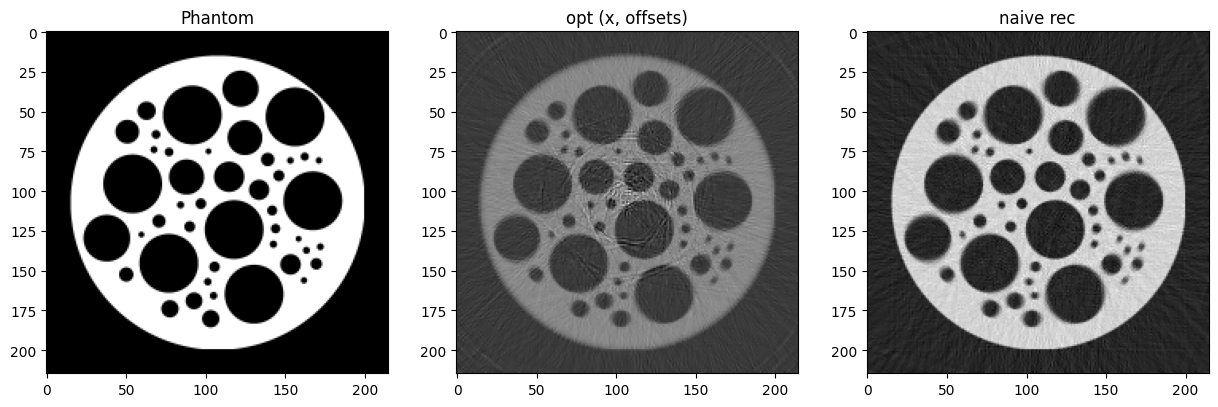

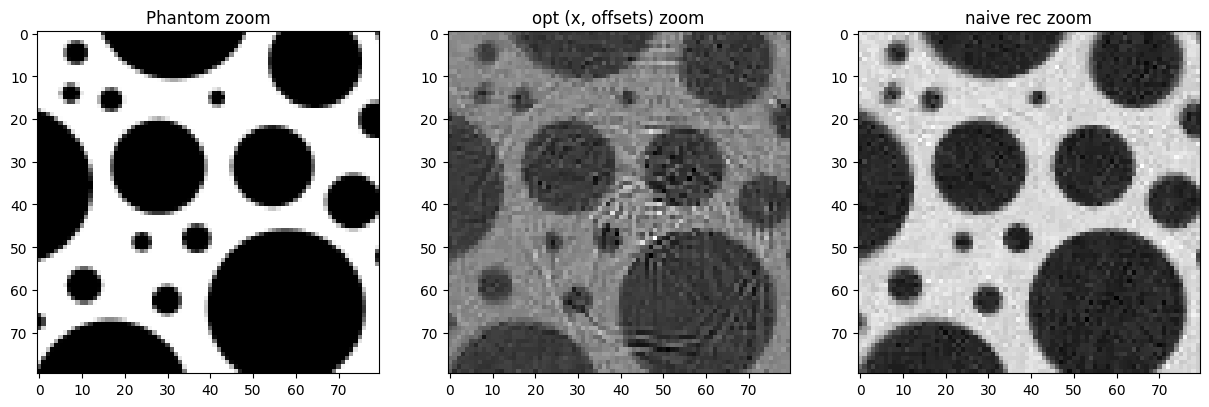

In [ ]:
from drjit.opt import Adam, GradScaler, SGD
tv = lambda x: dr.sum(dr.abs(x[1:] - x[:-1])) + dr.sum(dr.abs(x[:,1:] - x[:,:-1]))
def loss(x_input, t_offset_input):
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_perturbed,
        t_offset = t_offset_input
    )
    r = dr.custom(XRT, t_spec_dr, n_spec_dr, knot_spec, order, x_input, v_shape) - y_dr + 0.0001*tv(dr.reshape(TensorXf(x_input), v_shape))
    # r = xtk.xrt_apply((t_spec_dr, n_spec_dr), knot_spec, order, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x = dr.zeros_like(x_dr)
t = t_offset_perturbed
opt = Adam(lr=0.005, params={'x': x, 't': t})
# opt = SGD(lr=0.005, params={'x': x, 't': t})

scaler = GradScaler()
opt.set_learning_rate({'x': 2}) # 2 for adam, 2 for sgd
opt.set_learning_rate({'t': 0.01}) # 0.0005 for adam, 0.05 for sgd

for i in range(2000):
    x[:] = Float(opt['x'])
    t[:] = Float(opt['t']) 
    l = loss(x, t) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, dr.norm(opt['t'] - dr.linspace(Float, -(v_shape[0] - 1) / 2 * dr.sqrt(2.0), (v_shape[0] - 1) / 2 * dr.sqrt(2.0), 2*v_shape[0])))

x_opt = opt['x']
t_opt = opt['t']

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape), cmap='gray')
plt.title('opt (x, offsets)') 
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive rec')

# zooms on a region
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('Phantom zoom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('opt (x, offsets) zoom')
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('naive rec zoom')

print(dr.sum(x_opt - x_sol))
#59.6s with for loop, 45.2 with while loop (evaluated), 22.2 with "manual" while loop dr.hint

Text(0.5, 1.0, 'naive rec zoom')

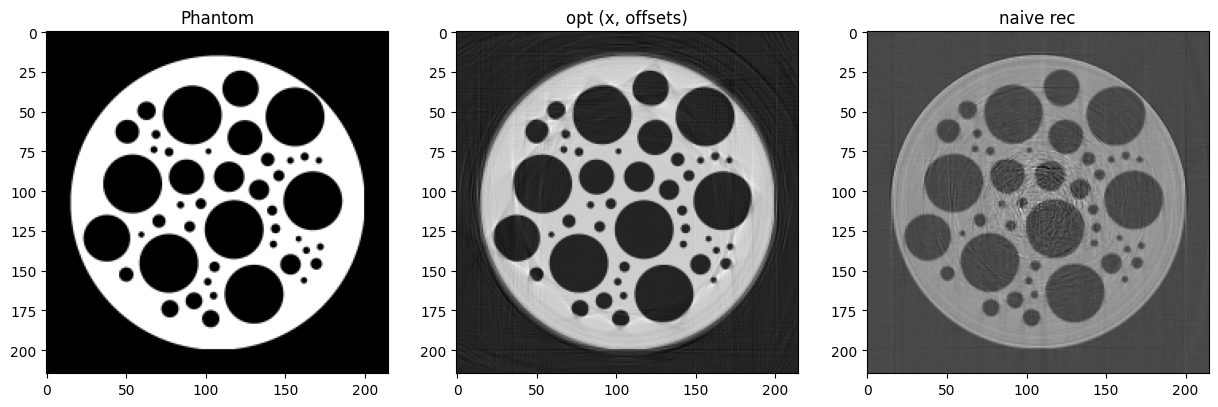

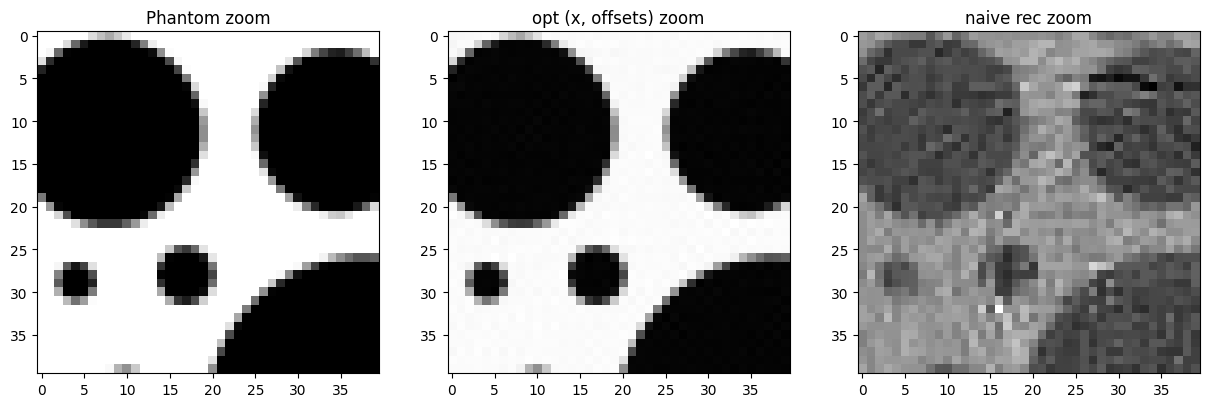

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape), cmap='gray')
plt.title('opt (x, offsets)') 
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive rec')

# zooms on a region
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('Phantom zoom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('opt (x, offsets) zoom')
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape)[60:140, 60:140], cmap='gray')
plt.title('naive rec zoom')

### ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
t_spec_dr, n_spec_dr = ray_spec
dr.enable_grad(x_dr, t_spec_dr, n_spec_dr)
r = xtk.xrt_apply((t_spec_dr, n_spec_dr), knot_spec, order, x_dr)
dr.backward(r)
r = xtk.xrt_apply((t_spec_dr, n_spec_dr), knot_spec, order, x_dr)
dr.backward(r)
print(x_dr.grad)
print(np.asarray(t_spec_dr.grad).max())
print(np.asarray(n_spec_dr.grad).max())

[1770.57, 1866.85, 1841.01, .. 46219 skipped .., 1877.76, 1859.01, 1823.38]
56000.223
0.0


3 [112484] [0.173888]
103 [128.065] [0.0698666]
203 [65.4469] [0.0356969]
303 [45.4904] [0.0235927]
403 [34.4952] [0.0163574]
503 [27.4434] [0.0116949]
603 [22.8731] [0.00872421]
703 [19.1479] [0.00658006]
803 [16.4564] [0.00522414]
903 [14.4663] [0.00433063]
1003 [13.167] [0.00378115]
1103 [12.2515] [0.00344443]
1203 [11.2264] [0.0031359]
1303 [10.4646] [0.00296713]
1403 [10.0909] [0.00286678]
1503 [9.83144] [0.00281859]
1603 [9.75768] [0.00280702]
1703 [9.72592] [0.00279678]
1803 [9.68809] [0.00278789]
1903 [9.64996] [0.00278017]
2003 [9.61879] [0.00277397]
2103 [9.58816] [0.00276955]
2203 [9.56157] [0.00276697]
2303 [25.8062] [0.00281076]
2403 [9.4212] [0.0024856]
2503 [9.40526] [0.00248547]
2603 [11.5592] [0.00247821]
2703 [9.50716] [0.00236185]
2803 [8.94818] [0.00233625]
2903 [8.8539] [0.00227281]
3003 [10.8913] [0.00222267]
3103 [8.34862] [0.00205443]
3203 [8.16555] [0.00199273]
3303 [13.0242] [0.00204694]
3403 [8.04744] [0.00196012]
3503 [8.08162] [0.00196473]
3603 [8.28247] [0

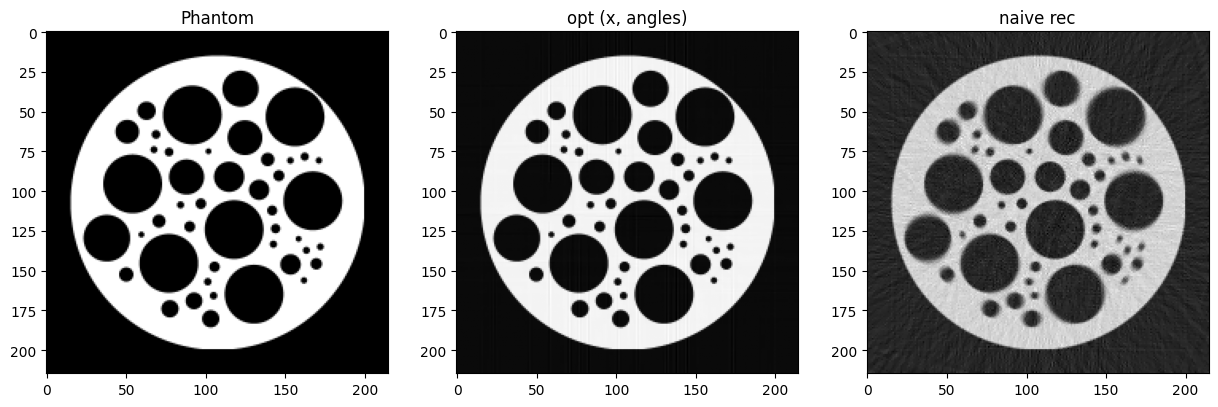

In [16]:
from drjit.opt import Adam, GradScaler, SGD
tv = lambda x: dr.sum(dr.abs(x[1:] - x[:-1])) + dr.sum(dr.abs(x[:,1:] - x[:,:-1]))
def loss(x_input, angles_input):
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_input,
        t_offset = t_offset_perturbed
    )
    ray_spec = (t_spec_dr, n_spec_dr)
    # r = xtk.xrt_apply(ray_spec, knot_spec, order, x_input) - y_dr
    r = dr.custom(XRT, t_spec_dr, n_spec_dr, knot_spec, order, x_input, v_shape) - y_dr
    return 0.5*dr.mean(r**2) + 0.0001*tv(dr.reshape(TensorXf(x_input), v_shape))

x_init = dr.zeros_like(x_dr)
angles_init = dr.copy(angles_perturbed)

x = x_init
ang = angles_init

opt = Adam(lr=0.005, params={'x': x, 'v': ang})
# opt = SGD(lr=0.00005, params={'x': x, 'v': ang})

scaler = GradScaler()
opt.set_learning_rate({'x': 3}) # 3 for adam, 2 for sgd
opt.set_learning_rate({'v': 0.0003}) # 0.0005 for adam, 0.00005 for sgd

for i in range(10000):
    x[:] = Float(opt['x'])
    ang[:] = Float(opt['v']) 
    l = loss(x, ang) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 3:
        print(i, l, 0.5*dr.sum((angles - ang)**2))

x_opt = opt['x']
angles_opt = opt['v']

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape), cmap='gray')
plt.title('opt (x, angles)') 
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive rec')

print(dr.sum(x_opt - x_sol))
#59.6s with for loop, 45.2 with while loop (evaluated), 22.2 with "manual" while loop dr.hint

### Spline-based calibration

0 [288730] [0.0102455]
100 [27.003] [0.00314809]
200 [9.79728] [0.00175147]
300 [6.32317] [0.00129575]
400 [5.0298] [0.00104582]
[9.00221]


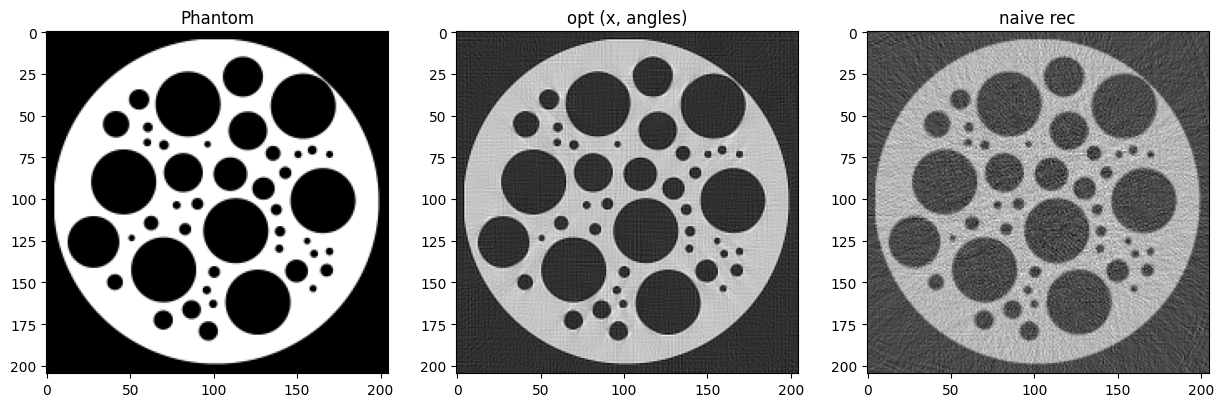

In [ ]:
# important test : order is 1 so we dont get stuck because of pixel derivatives

from drjit.opt import Adam, GradScaler, SGD

def loss(x_input, angles_input):
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_input
    )

    ray_spec = (dr.detach(t_spec_dr), n_spec_dr)
    r = xtk.xrt_apply(ray_spec, knot_spec, 2, x_input) - y_dr
    # r = xrt.eval(ray_spec, knot_spec, order, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x_init = dr.zeros_like(x_dr)
angles_init = dr.copy(angles_perturbed)

x = x_init
ang = angles_init

opt = Adam(lr=0.005, params={'x': x, 'v': ang})
# opt = SGD(lr=0., params={'x': x, 'v': ang})

scaler = GradScaler()
opt.set_learning_rate({'x': 3}) # 3 for adam, 2 for sgd
opt.set_learning_rate({'v': 0.0005}) # 0.0005 for adam, 0.00005 for sgd

for i in range(500):
    x[:] = Float(opt['x'])
    ang[:] = Float(opt['v']) + dr.rng().random(Float, shape=ang.shape) * 0.001
    l = loss(x, ang) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, 0.5*dr.sum((angles - ang)**2))

x_opt = opt['x']
angles_opt = opt['v']

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape), cmap='gray')
plt.title('opt (x, angles)') 
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive rec')

print(dr.sum(x_opt - x_sol))
#59.6s with for loop, 45.2 with while loop (evaluated), 22.2 with "manual" while loop dr.hint

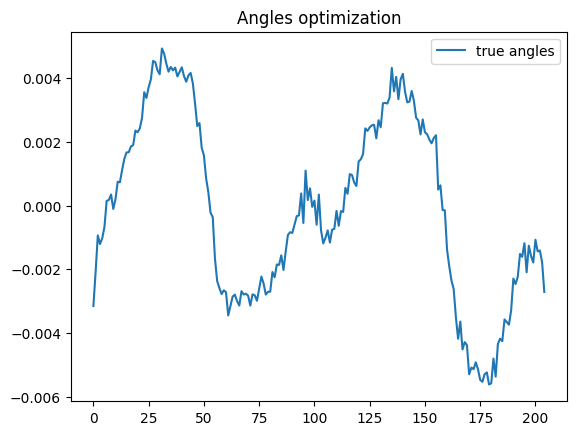

In [ ]:
plt.figure()
plt.plot(th.asarray(angles-angles_opt).cpu(), label='true angles')
# plt.plot(th.asarray(angles_perturbed).cpu(), label='perturbed angles')
# plt.plot(th.asarray(angles_opt).cpu(), label='optimized angles')
plt.legend()
plt.title('Angles optimization')
plt.show()

## -----------------------------------------------------------------------------------

## Cone beam

In [19]:
from pixe_pyxu import *

dataset, dws = "bin2", 2
rx_pitch = (127e-3, 127e-3)  # 0.127 [mm] detector/receiver pitch (height, width)
froot = Path("/scratch/haouchat/pixe/M2EA99-000").expanduser()
fpath = froot / dataset

In [20]:
sod, sdd, v_shape, v_pitch, P = get_info(fpath)
v_shape = (v_shape[0], v_shape[2])
P = P[:, P.shape[1]//2, :]
P  = -np.log(P/P.max())
y_dr = Float(P.reshape(-1))
N_view, N_w = P.shape
size = 640
shift_cor = +0.293 

In [21]:
@th.enable_grad()
@dr.wrap(source='drjit', target='torch')
def setOperator_th(
    sod, sdd, N_view, N_h, N_w, v_pitch, rx_pitch, dws, shift_cor=0.0,
    *, dtype=th.float32, device=None
):
    """
    PyTorch (imported as th) version of setOperator.

    Returns
    -------
    t_spec: (N_view * N_h * N_w, 2) th.Tensor
    n_spec: (N_view * N_h * N_w, 2) th.Tensor
    """

    if device is None:
        device = th.device("cpu")

    # Shapes
    v_shape = (N_view, N_h, N_w)
    v_pitch = (1.0, 1.0, 1.0)

    # Unit conversions to mm
    rx_pitch = (rx_pitch[0] / 0.0319955, rx_pitch[1] / 0.0319955)
    shift_cor = shift_cor / 0.0319955
    sod = th.full((1,), sod / 0.0319955, dtype=dtype, device=device)
    sdd = sdd / 0.0319955

    # Detector extents
    rx_h = th.full((1,), rx_pitch[0] * dws * N_h, dtype=dtype, device=device)
    rx_w = rx_pitch[1] * dws * N_w

    # TX position
    tx_pos = th.cat((shift_cor, rx_h / 2.0, sod))

    # RX lower-left corner
    rx_ll = th.tensor(
        [-rx_w / 2.0 + shift_cor, 0.0, sod - sdd],
        dtype=dtype, device=device, requires_grad=True
    )

    # Meshgrid for detector pixel centers
    Y1d = (0.5 * rx_pitch[0] * dws) + th.arange(N_h, dtype=dtype, device=device) * (rx_pitch[0] * dws)
    X1d = (0.5 * rx_pitch[1] * dws) + th.arange(N_w, dtype=dtype, device=device) * (rx_pitch[1] * dws)
    Z1d = th.tensor([0.0], dtype=dtype, device=device)

    Y, X, Z = th.meshgrid(Y1d, X1d, Z1d, indexing="ij")

    rx_pos = rx_ll + th.cat([X, Y, Z], dim=-1)  # (N_h, N_w, 3)

    # Volume (kept for consistency, not returned)
    v_dim = th.tensor(v_shape, dtype=dtype, device=device) * th.tensor(v_pitch, dtype=dtype, device=device)
    v_center = th.tensor([0.0, rx_h / 2.0, 0.0], dtype=dtype, device=device)
    v_ll_vec = v_center - v_dim / 2.0

    # Ray parameterization
    n_spec = (rx_pos - tx_pos).reshape(-1, 3)#.requires_grad_(True)
    t_spec = tx_pos.unsqueeze(0).expand_as(n_spec)#.requires_grad_(True)

    # Rotations
    angle = -th.linspace(0, 2 * th.pi - 2*th.pi/N_view, steps=N_view, dtype=dtype, device=device)
    R = th.zeros((N_view, 3, 3), dtype=dtype, device=device)
    R[:, 0, 0] = th.cos(angle)
    R[:, 2, 2] = th.cos(angle)
    R[:, 2, 0] = th.sin(angle)
    R[:, 0, 2] = -th.sin(angle)
    R[:, 1, 1] = 1.0

    # Apply rotations
    n_spec = th.matmul(n_spec, R.transpose(1, 2)).reshape(-1, 3)
    t_spec = th.matmul(t_spec, R.transpose(1, 2)).reshape(-1, 3)

    # Keep only (x, z)
    n_spec = n_spec[:, [0, 2]]
    t_spec = t_spec[:, [0, 2]]

    # Not returned, but computed like original
    v_ll = (float(v_ll_vec[0].item()), float(v_ll_vec[2].item()))
    v_shape_xz = (v_shape[0], v_shape[2])
    v_pitch_xz = (1.0, 1.0)
    _ = (v_ll, v_shape_xz, v_pitch_xz)

    return t_spec.T, n_spec.T


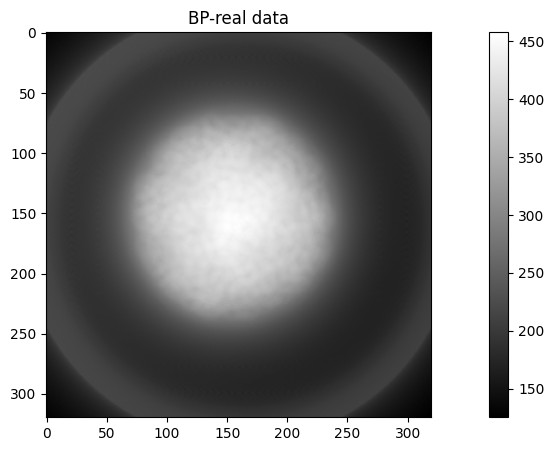

In [22]:
scale = 2

t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=th.tensor([0.],dtype=th.float32, device=device), dtype=th.float32, device=device)
ray_spec_th = (Array2f(t_spec_th), Array2f(n_spec_th))
knot_spec = xtk.UniformSpec(start=(-(size * 1.**2)/2, -(size * 1.**2)/2), step=(scale, scale), num=(size//scale, size//scale))
backproj_th = xtk.xrt_adjoint(ray_spec_th, knot_spec, 0, y_dr)

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(backproj_th).cpu().reshape(size//scale, size//scale), cmap='gray')
plt.title('BP-real data')
plt.colorbar()

## Naive optimizazion (x only)

0 [0.0570186]
100 [0.00230777]
200 [0.00227929]
300 [0.00227081]
400 [0.00226701]
500 [0.00226496]
600 [0.00226371]
700 [0.00226288]
800 [0.00226227]
900 [0.00226181]


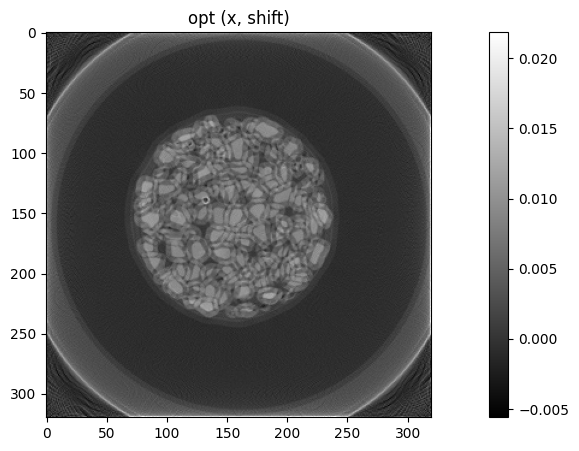

In [23]:
from drjit.opt import Adam, GradScaler, SGD
from drjit.cuda.ad import Float32

def loss(x_input):
    t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=th.tensor([-0.15],dtype=th.float32, device=device), dtype=th.float32, device=device)
    ray_spec = (Array2f(t_spec_th), Array2f(n_spec_th))
    r = xtk.xrt_apply(ray_spec, knot_spec, 0, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x = dr.zeros_like(backproj_th)
dr.enable_grad(x)

# opt = Adam(lr=0., params={'x': x, 'v': shift})
opt = SGD(lr=0., params={'x': x})
scaler = GradScaler()

opt.set_learning_rate({'x': 5}) # 5 for adam
for i in range(1000):
    x[:] = Float(opt['x'])
    l = loss(x) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l)

x_opt = opt['x']

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(x_opt).cpu().reshape((size//scale, size//scale)), cmap='gray')
plt.title('opt (x, shift)')
plt.colorbar()


### test shift opt with custom AD

In [30]:
class XRT(dr.CustomOp):
    def eval(self, t_spec_dr, n_spec_dr, knot_spec, order, x):
        # Stash everything we need for the backward pass
        self.t_spec_dr = t_spec_dr
        self.n_spec_dr = n_spec_dr
        self.knot_spec = knot_spec
        self.order = order
        self.x = x
        
        x_th = th.asarray(x).reshape((320,320))
        self.diff_x = th.clone(x_th)
        self.diff_x[:, 1:] -= x_th[:, :-1]
        self.diff_x = Float(x_th.reshape(-1))
        self.diff_y = th.clone(x_th)
        self.diff_y[1:, :] -= x_th[:-1, :]
        self.diff_y = Float(x_th.reshape(-1))

        ray_spec = (t_spec_dr, n_spec_dr)
        return xtk.xrt_apply(ray_spec, knot_spec, order, x)

    def forward(self):
        raise RuntimeError("XRT: forward-mode differentiation not implemented")

    def backward(self):
        grad_x = xtk.xrt_adjoint((self.t_spec_dr, self.n_spec_dr), self.knot_spec, self.order, self.grad_out())
        self.set_grad_in('x', grad_x) 

        grad_t = dr.zeros(TensorXf, t_spec_dr.shape)
        P_x = xtk.xrt_ad_n_x((self.t_spec_dr, self.n_spec_dr),
                         self.knot_spec, self.order, self.diff_x)
        P_y = xtk.xrt_ad_n_y((self.t_spec_dr, self.n_spec_dr),
                            self.knot_spec, self.order, self.diff_y)

        print(grad_t.shape)
        print(P_x.shape)
        grad_t_x = self.grad_out() * P_x   # (num_offsets,)
        grad_t_y = self.grad_out() * P_y   # (num_offsets,)
        grad_t[0, :] = grad_t_x
        grad_t[1, :] = grad_t_y
        self.set_grad_in('t_spec_dr', grad_t)

    def name(self):
        return "xrt"


In [31]:
import math
from drjit.opt import Adam, GradScaler, SGD
from drjit.cuda.ad import Float32

def loss(x_input, shift_input):
    t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=shift_input, dtype=th.float32, device=device)
    # r = xtk.xrt_apply(ray_spec, knot_spec, 0, x_input) - y_dr
    r = dr.custom(XRT, Array2f(t_spec_th), Array2f(n_spec_th), knot_spec, order, x_input) - y_dr

    return 0.5*dr.mean(r**2)

x = dr.zeros_like(backproj_th)
shift = Float32(0)
dr.enable_grad(shift)
dr.enable_grad(x)

# opt = Adam(lr=0., params={'x': x, 'v': shift})
opt = SGD(lr=0., params={'x': x, 'v': shift})
scaler = GradScaler()

opt.set_learning_rate({'x': 5}) # 5 for adam
opt.set_learning_rate({'v': 5}) # 0.005 for adam
for i in range(1000):
    x[:] = Float(opt['x'])
    shift = Float32(opt['v'])
    l = loss(x, shift) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, opt['v'])

x_opt = opt['x']
shift_opt = opt['v']

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(x_opt).cpu().reshape((size//scale, size//scale)), cmap='gray')
plt.title('opt (x, shift)')
plt.colorbar()


(2, 184900)
(582400,)


TypeError: drjit.cuda.ad.TensorXf.__setitem__(): jit_var_scatter(r823, r1199, r1974): operands have incompatible sizes! (sizes: 582400, 184900, 1)

## Shift correction optimization

In [19]:
from drjit.opt import Adam, GradScaler, SGD
from drjit.cuda.ad import Float32

def loss(x_input, shift_input):
    t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=shift_input, dtype=th.float32, device=device)
    ray_spec = (Array2f(t_spec_th), Array2f(n_spec_th))
    r = xtk.xrt_apply(ray_spec, knot_spec, 0, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x = dr.zeros_like(backproj_th)
shift = Float32(0)
dr.enable_grad(shift)
dr.enable_grad(x)

# opt = Adam(lr=0., params={'x': x, 'v': shift})
opt = SGD(lr=0., params={'x': x, 'v': shift})
scaler = GradScaler()

opt.set_learning_rate({'x': 5}) # 5 for adam
opt.set_learning_rate({'v': 5}) # 0.005 for adam
for i in range(1000):
    x[:] = Float(opt['x'])
    shift = Float32(opt['v'])
    l = loss(x, shift) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, opt['v'])

x_opt = opt['x']
shift_opt = opt['v']

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(x_opt).cpu().reshape((size//scale, size//scale)), cmap='gray')
plt.title('opt (x, shift)')
plt.colorbar()


/tmp/ipykernel_17508/1125828460.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  rx_ll = th.tensor(


RuntimeError: dr.while_loop(): encountered an exception (see above).

## -----------------------------------------------------------------------